In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load TRAIN data only
train = pd.read_csv("train.csv")

print("Train shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())

train.head()

Train shape: (67533, 24)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'item_count', 'total_price', 'total_freight', 'payment_count', 'total_payment', 'max_installments', 'review_count', 'avg_review_score', 'unique_products', 'unique_sellers', 'unique_categories', 'is_late']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_freight,payment_count,total_payment,max_installments,review_count,avg_review_score,unique_products,unique_sellers,unique_categories,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,8.49,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,...,15.56,1.0,45.46,1.0,1.0,4.0,1.0,1.0,1.0,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,...,17.19,1.0,39.09,1.0,1.0,4.0,1.0,1.0,1.0,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,b8b8726af116a5cfb35b0315ecef9172,22770,...,14.11,1.0,35.61,1.0,1.0,1.0,1.0,1.0,1.0,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,...,17.24,1.0,53.73,1.0,1.0,3.0,1.0,1.0,1.0,0


In [2]:
# Data types and missing values
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "missing_count": train.isnull().sum(),
    "missing_percent": (train.isnull().mean() * 100).round(2)
})

summary = summary.sort_values("missing_percent", ascending=False)

summary

,dtype,missing_count,missing_percent
avg_review_score,float64,515,0.76
review_count,float64,515,0.76
order_approved_at,object,14,0.02
order_id,object,0,0.00
order_purchase_timestamp,object,0,0.00
order_delivered_carrier_date,object,1,0.00
order_status,object,0,0.00
customer_id,object,0,0.00
order_estimated_delivery_date,object,0,0.00
order_delivered_customer_date,object,0,0.00


Target counts:
is_late
0    61436
1     6097
Name: count, dtype: int64

Target percentages:
is_late
0    90.97
1     9.03
Name: proportion, dtype: float64


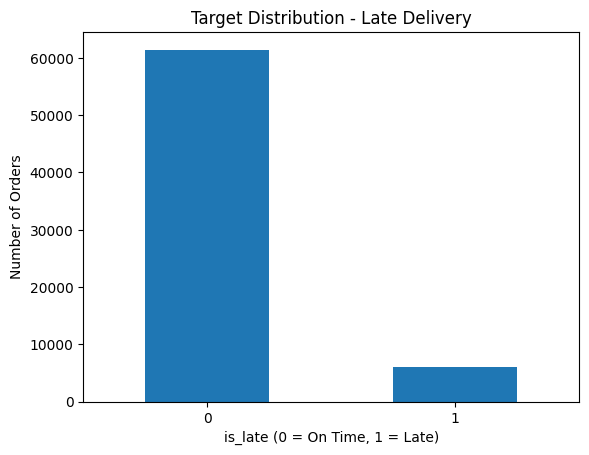

In [3]:
# Target distribution
target_counts = train["is_late"].value_counts().sort_index()
target_percent = train["is_late"].value_counts(
    normalize=True
).sort_index() * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent.round(2))

# Plot
target_counts.plot(
    kind="bar",
    title="Target Distribution - Late Delivery"
)

plt.xlabel("is_late (0 = On Time, 1 = Late)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [4]:
# Important numerical features
num_features = [
    "item_count",
    "total_price",
    "total_freight",
    "payment_count",
    "total_payment",
    "max_installments",
    "unique_products",
    "unique_sellers",
    "unique_categories"
]

# Summary statistics
print("Numerical Features Summary:")
display(train[num_features].describe().T)

# Compare averages: On-time vs Late
print("\nAverage values by target:")
display(
    train.groupby("is_late")[num_features]
         .mean()
         .T
         .rename(columns={0: "On_Time", 1: "Late"})
         .round(2)
)

Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
total_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
payment_count,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
total_payment,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08
max_installments,67532.0,2.974397,2.755007,1.00,1.00,2.00,4.000,24.00
unique_products,67533.0,1.037715,0.222223,1.00,1.00,1.00,1.000,7.00
unique_sellers,67533.0,1.012053,0.114812,1.00,1.00,1.00,1.000,5.00
unique_categories,67533.0,0.988968,0.156442,0.00,1.00,1.00,1.000,3.00



Average values by target:


is_late,On_Time,Late
item_count,1.14,1.11
total_price,134.51,149.77
total_freight,21.95,25.20
payment_count,1.05,1.04
total_payment,156.50,175.01
max_installments,2.96,3.12
unique_products,1.04,1.02
unique_sellers,1.01,1.00
unique_categories,0.99,0.98


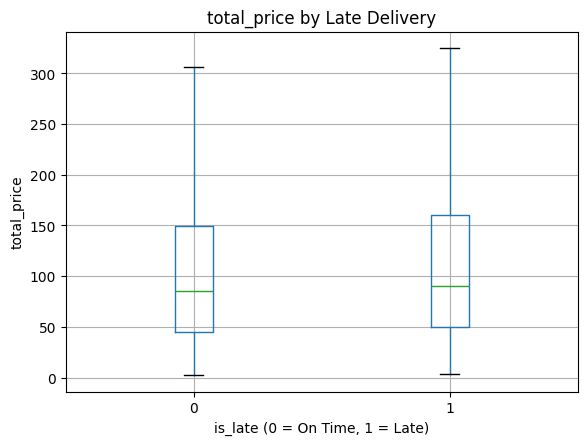

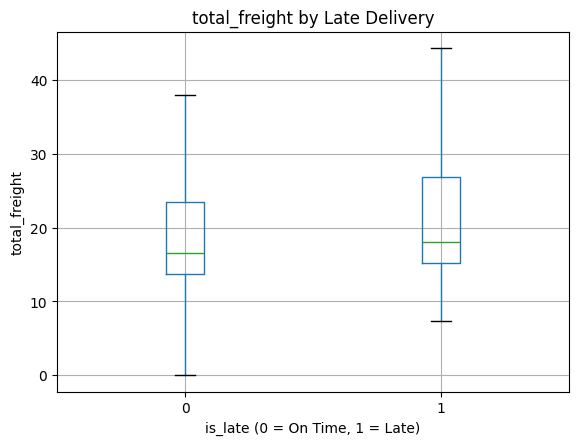

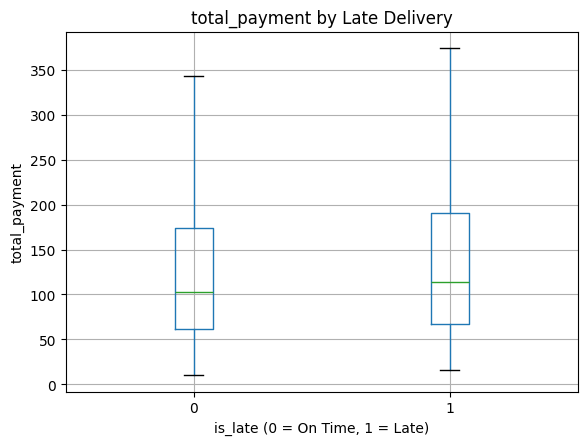

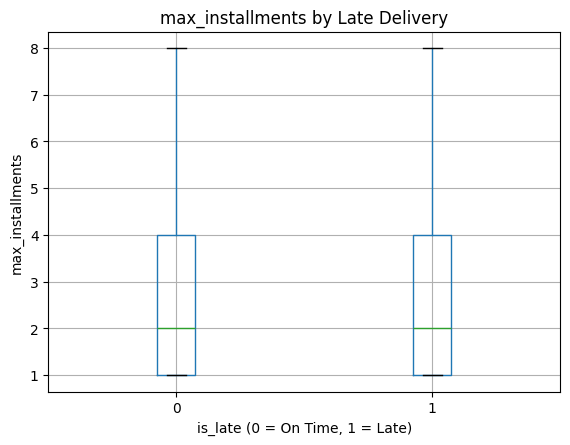

In [5]:
import matplotlib.pyplot as plt

features = [
    "total_price",
    "total_freight",
    "total_payment",
    "max_installments"
]

for feature in features:
    train.boxplot(column=feature, by="is_late", showfliers=False)
    plt.title(f"{feature} by Late Delivery")
    plt.suptitle("")
    plt.xlabel("is_late (0 = On Time, 1 = Late)")
    plt.ylabel(feature)
    plt.show()

In [6]:
categorical_cols = [
    "customer_city",
    "customer_state",
    "order_status"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", train[col].nunique())
    print(train[col].value_counts().head(10))


--- customer_city ---
Unique values: 3747
customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, dtype: int64

--- customer_state ---
Unique values: 27
customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64

--- order_status ---
Unique values: 2
order_status
delivered    67527
canceled         6
Name: count, dtype: int64


In [7]:
train["order_purchase_timestamp"] = pd.to_datetime(
    train["order_purchase_timestamp"]
)

train["purchase_month"] = train["order_purchase_timestamp"].dt.month
train["purchase_dayofweek"] = train["order_purchase_timestamp"].dt.dayofweek

print("Late rate by month:")
print(
    train.groupby("purchase_month")["is_late"]
         .mean()
         .mul(100)
         .round(2)
)

print("\nLate rate by day of week:")
print(
    train.groupby("purchase_dayofweek")["is_late"]
         .mean()
         .mul(100)
         .round(2)
)

Late rate by month:
purchase_month
1      6.23
2     13.42
3     17.15
4      7.02
5      3.61
6      3.86
7      3.43
8      3.32
9      5.23
10     5.05
11    14.31
12     8.38
Name: is_late, dtype: float64

Late rate by day of week:
purchase_dayofweek
0    10.02
1     9.26
2     8.61
3     8.29
4     9.47
5     8.97
6     8.38
Name: is_late, dtype: float64


In [8]:
print("Late rate by customer state:")

state_late_rate = (
    train.groupby("customer_state")["is_late"]
         .agg(["count", "mean"])
)

state_late_rate["late_percent"] = (
    state_late_rate["mean"] * 100
).round(2)

state_late_rate = state_late_rate.sort_values(
    "late_percent",
    ascending=False
)

display(state_late_rate.head(15))

Late rate by customer state:


,count,mean,late_percent
customer_state,,,
AL,298,0.278523,27.85
MA,548,0.215328,21.53
CE,948,0.182489,18.25
RR,29,0.172414,17.24
SE,246,0.170732,17.07
PI,348,0.166667,16.67
RJ,8967,0.165830,16.58
BA,2307,0.149978,15.00
PA,718,0.133705,13.37


In [9]:
print("EDA Findings Summary")
print("- The target is imbalanced, with late orders representing a small minority.")
print("- Late orders tend to have higher total price, freight, and payment values.")
print("- Clear monthly variation exists in late deliveries; March, November, and February have higher late rates.")
print("- Late-delivery rates vary across customer states, indicating a geographic pattern.")
print("- Weekday differences exist, but they are smaller than the monthly differences.")
print("- Customer city has high cardinality, with 3747 unique values.")
print("- Future information such as actual delivery dates and review scores should not be used as prediction features.")

EDA Findings Summary
- The target is imbalanced, with late orders representing a small minority.
- Late orders tend to have higher total price, freight, and payment values.
- Clear monthly variation exists in late deliveries; March, November, and February have higher late rates.
- Late-delivery rates vary across customer states, indicating a geographic pattern.
- Weekday differences exist, but they are smaller than the monthly differences.
- Customer city has high cardinality, with 3747 unique values.
- Future information such as actual delivery dates and review scores should not be used as prediction features.
